In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from src.riemannian import load_riemannian_features
from src.models import (
    build_svm, build_lda, build_rf,
    evaluate_model, save_model,
    save_metrics, run_all_visualizations
)

In [2]:
subjects      = ['A01T', 'A02T', 'A03T', 'A04T', 'A05T', 'A06T', 'A07T', 'A08T', 'A09T']
FEATURES_PATH = '../data/features_riemannian/'
MODELS_PATH   = '../results/models/riemannian/'
METRICS_PATH  = '../results/metrics/riemannian/'
FIGURES_PATH  = '../results/figures/training/riemannian/'
CLASS_NAMES   = ['Left Hand', 'Right Hand', 'Feet', 'Tongue']

os.makedirs(MODELS_PATH,  exist_ok=True)
os.makedirs(METRICS_PATH, exist_ok=True)
os.makedirs(FIGURES_PATH, exist_ok=True)

In [3]:
all_results = {}

for subject_id in subjects:
    print(f"\n{'='*50}")
    print(f"  {subject_id}")
    print(f"{'='*50}")

    X, y = load_riemannian_features(subject_id, load_path=FEATURES_PATH)

    models = {
        'SVM': build_svm(),
        'LDA': build_lda(),
        'RF':  build_rf()
    }

    all_results[subject_id] = {}

    for model_name, model in models.items():
        print(f"\n  Training {model_name}...")
        result = evaluate_model(model, X, y)
        print(f"  Accuracy: {result['mean']*100:.1f}% (+/- {result['std']*100:.1f}%)")
        print(f"  Per fold: {np.round(result['scores']*100, 1)}")

        model.fit(X, y)
        save_model(model, subject_id, f'Riemannian_{model_name}', save_path=MODELS_PATH)
        all_results[subject_id][model_name] = result

print("\nAll subjects done.")


  A01T
  Loaded A01T: X=(164, 253), y=(164,)

  Training SVM...
  Accuracy: 75.6% (+/- 3.1%)
  Per fold: [72.7 75.8 72.7 75.8 81.2]
Model saved to ../results/models/riemannian/A01T_Riemannian_SVM.pkl

  Training LDA...
  Accuracy: 78.7% (+/- 6.8%)
  Per fold: [72.7 75.8 72.7 81.8 90.6]
Model saved to ../results/models/riemannian/A01T_Riemannian_LDA.pkl

  Training RF...
  Accuracy: 78.0% (+/- 3.5%)
  Per fold: [81.8 81.8 72.7 75.8 78.1]
Model saved to ../results/models/riemannian/A01T_Riemannian_RF.pkl

  A02T
  Loaded A02T: X=(216, 253), y=(216,)

  Training SVM...
  Accuracy: 55.1% (+/- 8.6%)
  Per fold: [59.1 46.5 44.2 67.4 58.1]
Model saved to ../results/models/riemannian/A02T_Riemannian_SVM.pkl

  Training LDA...
  Accuracy: 59.7% (+/- 3.2%)
  Per fold: [61.4 53.5 60.5 62.8 60.5]
Model saved to ../results/models/riemannian/A02T_Riemannian_LDA.pkl

  Training RF...
  Accuracy: 56.5% (+/- 4.9%)
  Per fold: [54.5 60.5 55.8 62.8 48.8]
Model saved to ../results/models/riemannian/A02T_

In [4]:
print("RIEMANNIAN ACCURACY SUMMARY")
print("="*70)

rows = []
for subject_id in subjects:
    row = {'Subject': subject_id}
    for model_name in ['SVM', 'LDA', 'RF']:
        mean = all_results[subject_id][model_name]['mean']
        std  = all_results[subject_id][model_name]['std']
        row[model_name] = f"{mean*100:.1f}% (+/-{std*100:.1f}%)"
    rows.append(row)

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))

print()
print("AVERAGE ACROSS ALL SUBJECTS")
print("-"*40)
for model_name in ['SVM', 'LDA', 'RF']:
    avg = np.mean([all_results[s][model_name]['mean'] for s in subjects])
    std = np.std([all_results[s][model_name]['mean'] for s in subjects])
    print(f"  {model_name}: {avg*100:.1f}% (+/- {std*100:.1f}%)")
print(f"  Chance level: 25.0%")

results_df.to_csv(f'{METRICS_PATH}riemannian_accuracy_summary.csv', index=False)

RIEMANNIAN ACCURACY SUMMARY
Subject             SVM              LDA              RF
   A01T 75.6% (+/-3.1%)  78.7% (+/-6.8%) 78.0% (+/-3.5%)
   A02T 55.1% (+/-8.6%)  59.7% (+/-3.2%) 56.5% (+/-4.9%)
   A03T 83.2% (+/-6.4%)  88.3% (+/-5.4%) 81.0% (+/-4.5%)
   A04T 58.4% (+/-6.5%)  62.6% (+/-6.8%) 53.5% (+/-9.5%)
   A05T 41.0% (+/-9.6%) 41.0% (+/-12.8%) 38.6% (+/-4.6%)
   A06T 51.0% (+/-6.0%)  53.5% (+/-5.0%) 47.8% (+/-4.1%)
   A07T 76.7% (+/-6.0%) 72.6% (+/-11.0%) 74.7% (+/-8.8%)
   A08T 88.4% (+/-3.4%)  90.5% (+/-4.1%) 81.7% (+/-3.7%)
   A09T 68.5% (+/-9.6%)  69.6% (+/-5.9%) 69.6% (+/-6.8%)

AVERAGE ACROSS ALL SUBJECTS
----------------------------------------
  SVM: 66.4% (+/- 15.0%)
  LDA: 68.5% (+/- 15.2%)
  RF: 64.6% (+/- 15.0%)
  Chance level: 25.0%


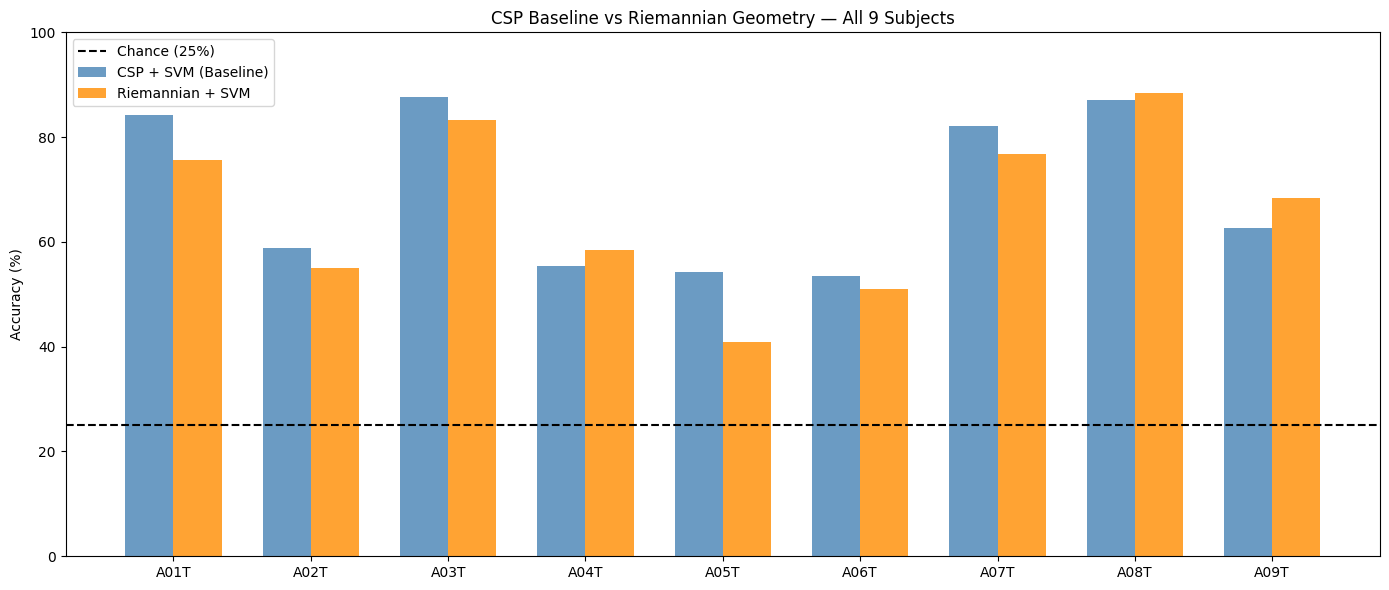

In [5]:
# Compare CSP baseline vs Riemannian

baseline_csv   = pd.read_csv('../results/metrics/baseline/accuracy_summary.csv')
baseline_svm   = baseline_csv['SVM_mean'].values
riemannian_svm = [all_results[s]['SVM']['mean'] * 100 for s in subjects]

x     = np.arange(len(subjects))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, baseline_svm,   width, label='CSP + SVM (Baseline)',
       color='steelblue', alpha=0.8)
ax.bar(x + width/2, riemannian_svm, width, label='Riemannian + SVM',
       color='darkorange', alpha=0.8)

ax.axhline(y=25, color='black', linestyle='--', linewidth=1.5, label='Chance (25%)')
ax.set_xticks(x)
ax.set_xticklabels(subjects)
ax.set_ylabel('Accuracy (%)')
ax.set_title('CSP Baseline vs Riemannian Geometry — All 9 Subjects')
ax.legend()
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}csp_vs_riemannian.png', dpi=100)
plt.show()

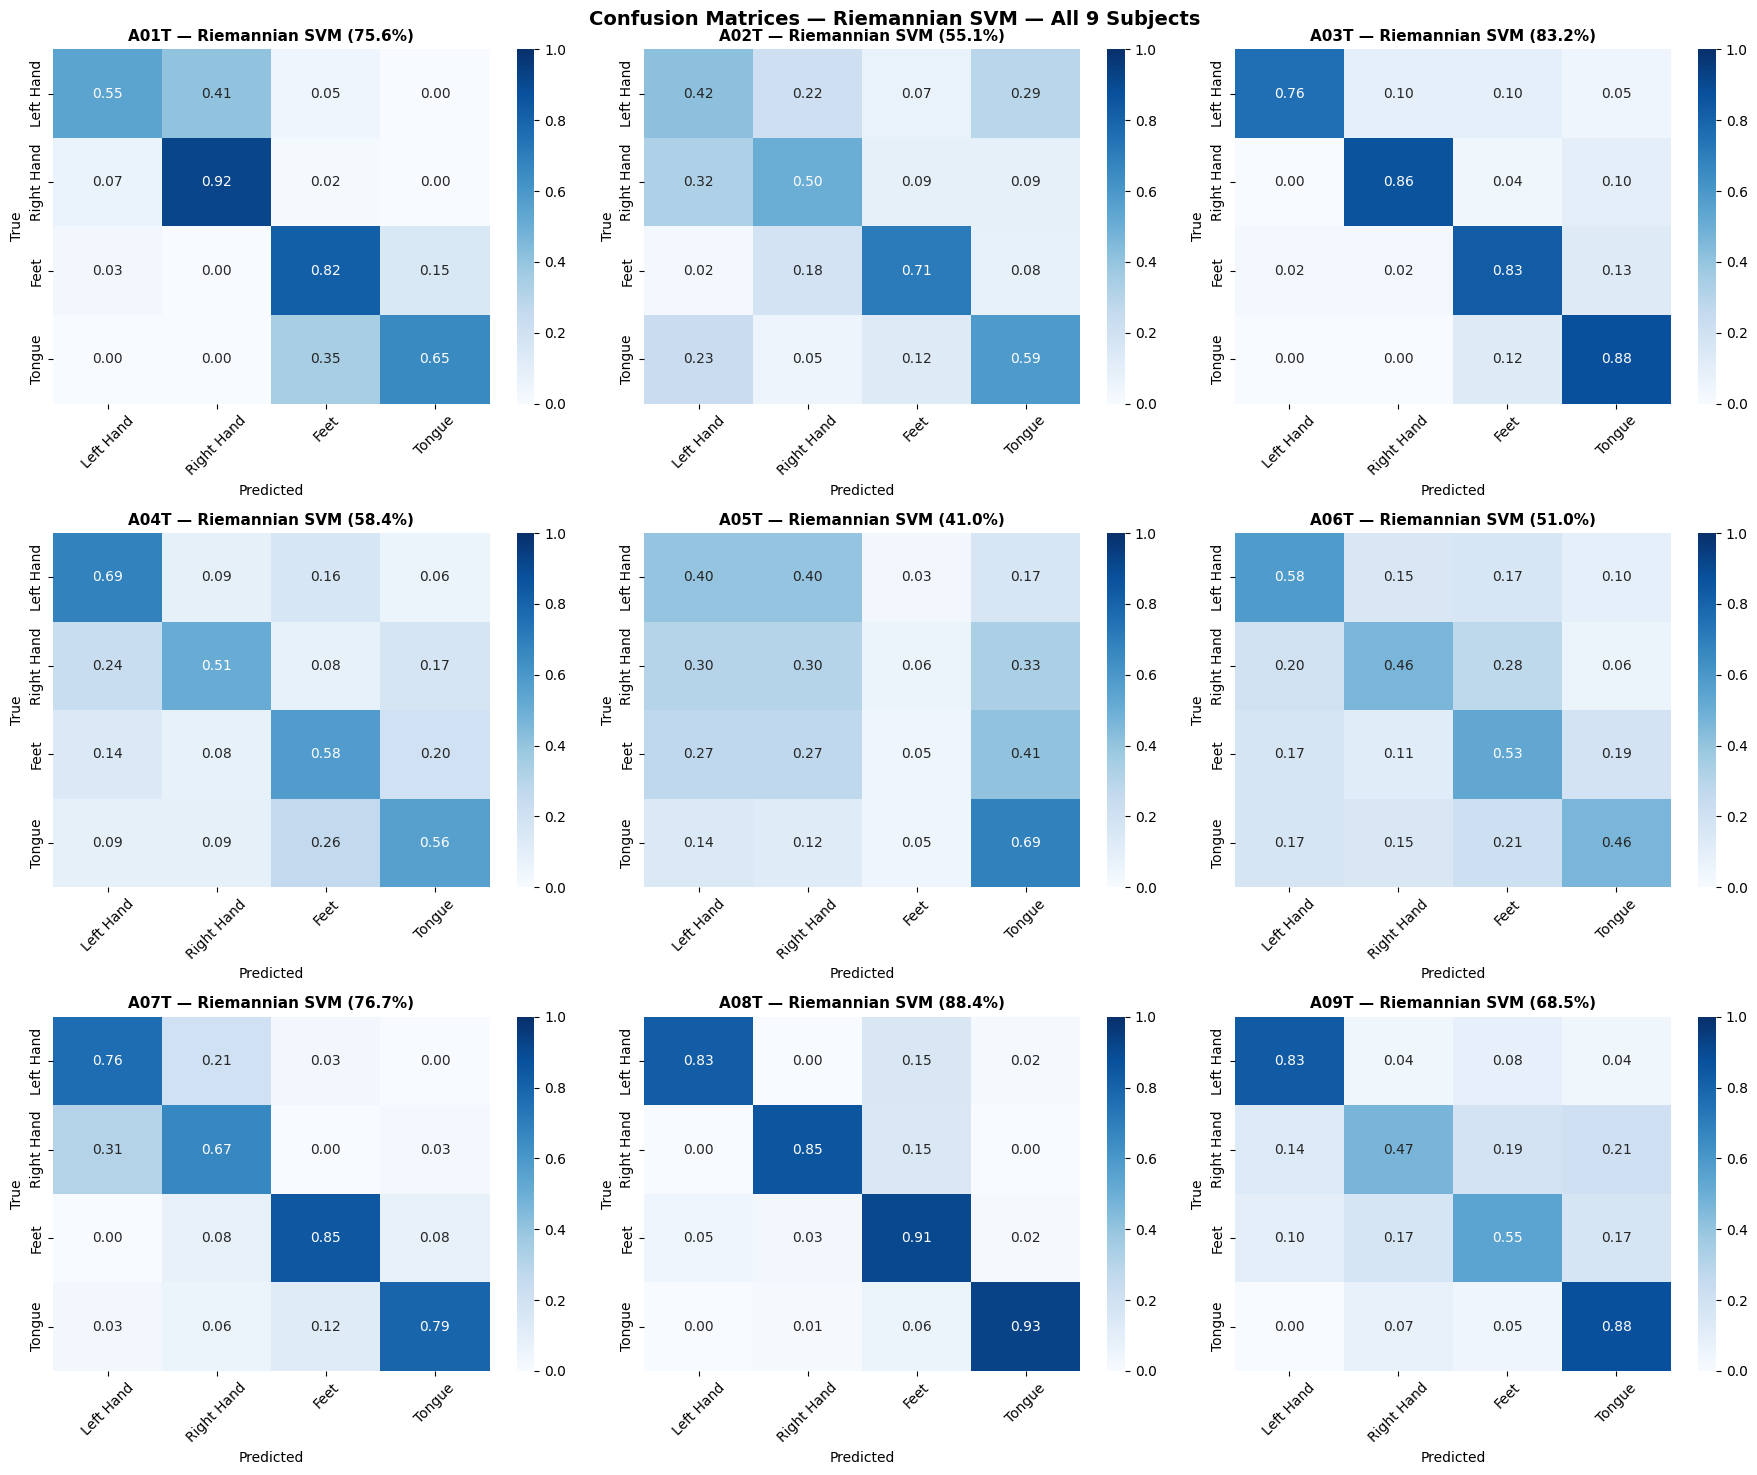

In [6]:
# Confusion matrices for Riemannian SVM

fig, axes = plt.subplots(3, 3, figsize=(18, 15))

for ax, subject_id in zip(axes.flat, subjects):
    cm      = all_results[subject_id]['SVM']['cm']
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        ax=ax,
        vmin=0, vmax=1
    )
    acc = all_results[subject_id]['SVM']['mean'] * 100
    ax.set_title(f"{subject_id} — Riemannian SVM ({acc:.1f}%)",
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Confusion Matrices — Riemannian SVM — All 9 Subjects',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}confusion_matrices_riemannian_svm.png', dpi=100)
plt.show()

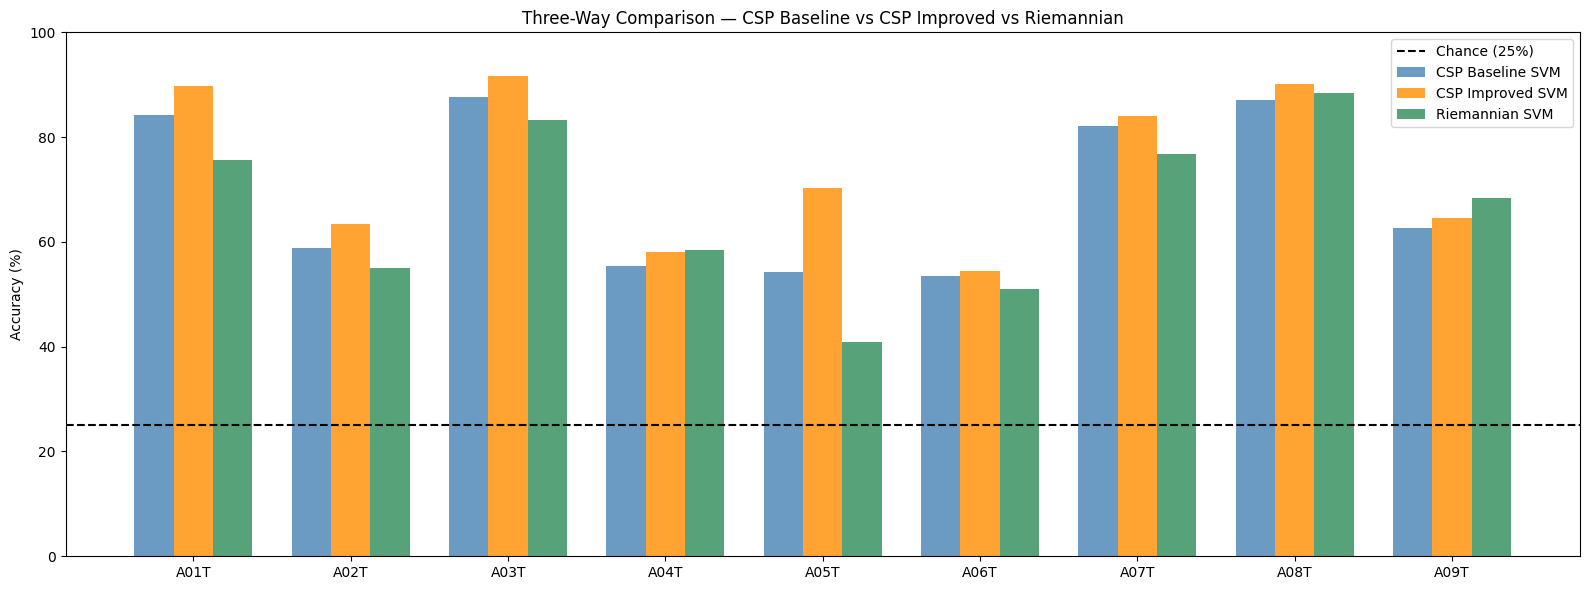

In [9]:
# Load CSVs
baseline_csv = pd.read_csv('../results/metrics/baseline/accuracy_summary.csv')
improved_csv = pd.read_csv('../results/metrics/improved/improved_accuracy_summary.csv')

# Extract numeric value from string like "89.8% (+/-3.6%)"
def extract_acc(val):
    return float(str(val).split('%')[0])

baseline_svm   = baseline_csv['SVM_mean'].values
improved_svm   = improved_csv['SVM_tuned'].apply(extract_acc).values
riemannian_svm = [all_results[s]['SVM']['mean'] * 100 for s in subjects]

x     = np.arange(len(subjects))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - width, baseline_svm,   width, label='CSP Baseline SVM',
       color='steelblue',  alpha=0.8)
ax.bar(x,         improved_svm,   width, label='CSP Improved SVM',
       color='darkorange', alpha=0.8)
ax.bar(x + width, riemannian_svm, width, label='Riemannian SVM',
       color='seagreen',   alpha=0.8)

ax.axhline(y=25, color='black', linestyle='--', linewidth=1.5, label='Chance (25%)')
ax.set_xticks(x)
ax.set_xticklabels(subjects)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Three-Way Comparison — CSP Baseline vs CSP Improved vs Riemannian')
ax.legend()
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}three_way_comparison.png', dpi=100)
plt.show()

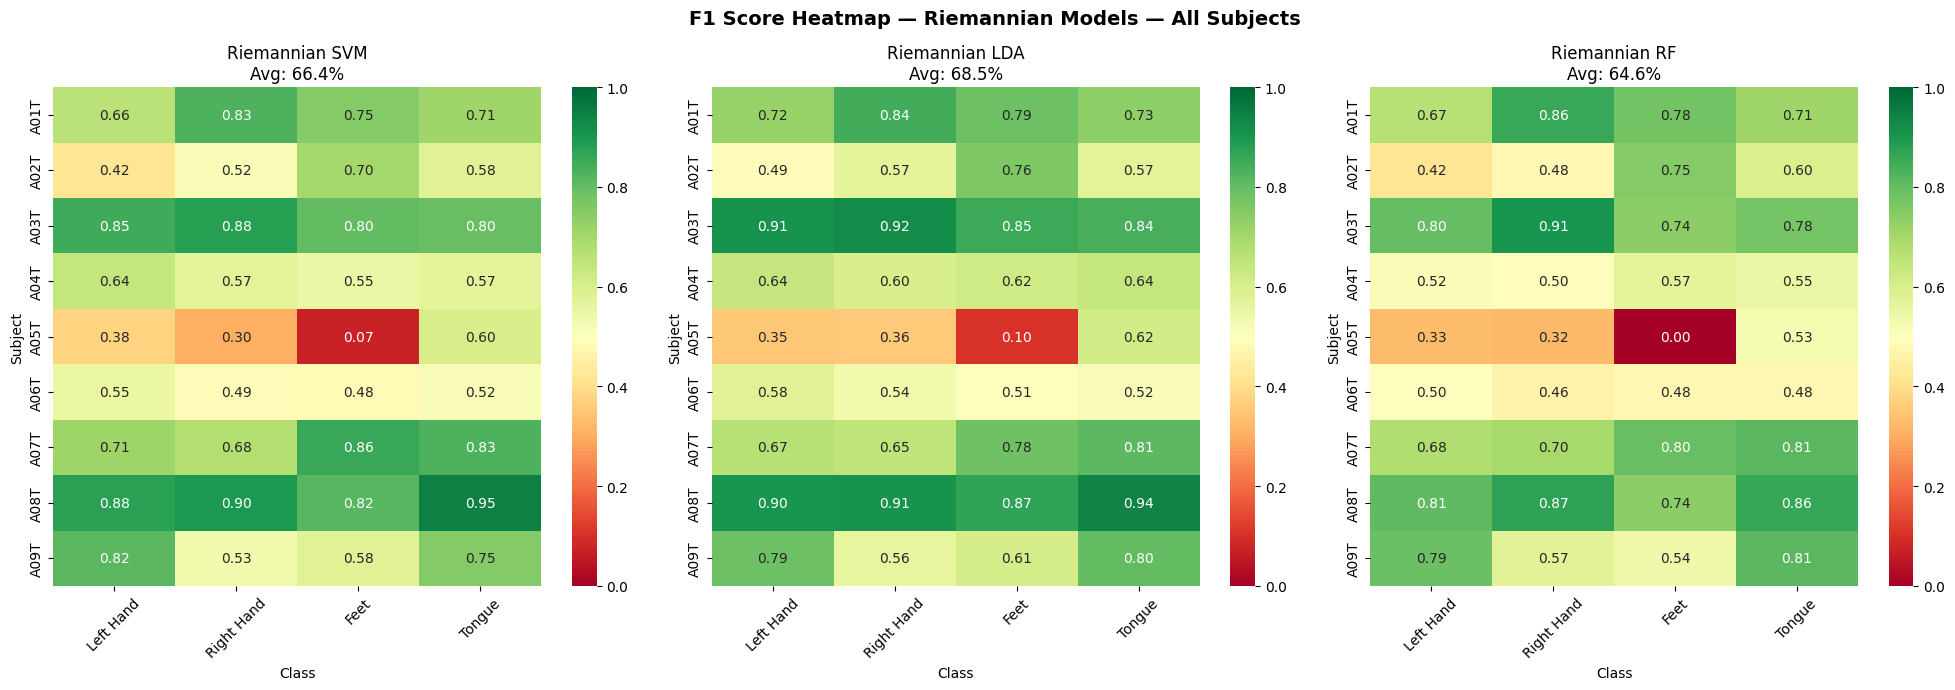

In [10]:
# F1 heatmap for Riemannian models

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, model_name in zip(axes, ['SVM', 'LDA', 'RF']):
    f1_matrix = []
    for subject_id in subjects:
        report = all_results[subject_id][model_name]['report']
        f1_row = [report[cls]['f1-score'] for cls in CLASS_NAMES]
        f1_matrix.append(f1_row)

    sns.heatmap(
        np.array(f1_matrix),
        annot=True,
        fmt='.2f',
        cmap='RdYlGn',
        xticklabels=CLASS_NAMES,
        yticklabels=subjects,
        ax=ax,
        vmin=0, vmax=1
    )
    avg = np.mean([all_results[s][model_name]['mean'] for s in subjects])
    ax.set_title(f'Riemannian {model_name}\nAvg: {avg*100:.1f}%')
    ax.set_xlabel('Class')
    ax.set_ylabel('Subject')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('F1 Score Heatmap — Riemannian Models — All Subjects',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}f1_heatmap_riemannian.png', dpi=100)
plt.show()

Saved accuracy_summary.csv
Saved per_class_metrics.csv
Saved per_fold_scores.csv

Generating all training visualizations...


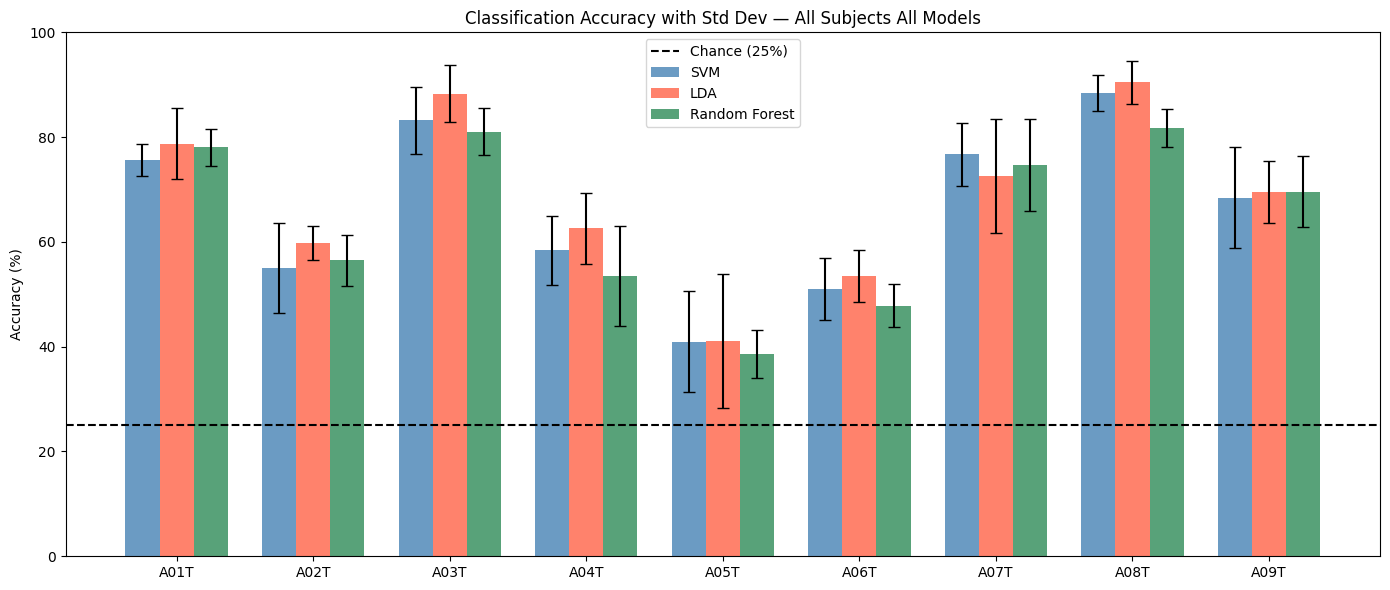

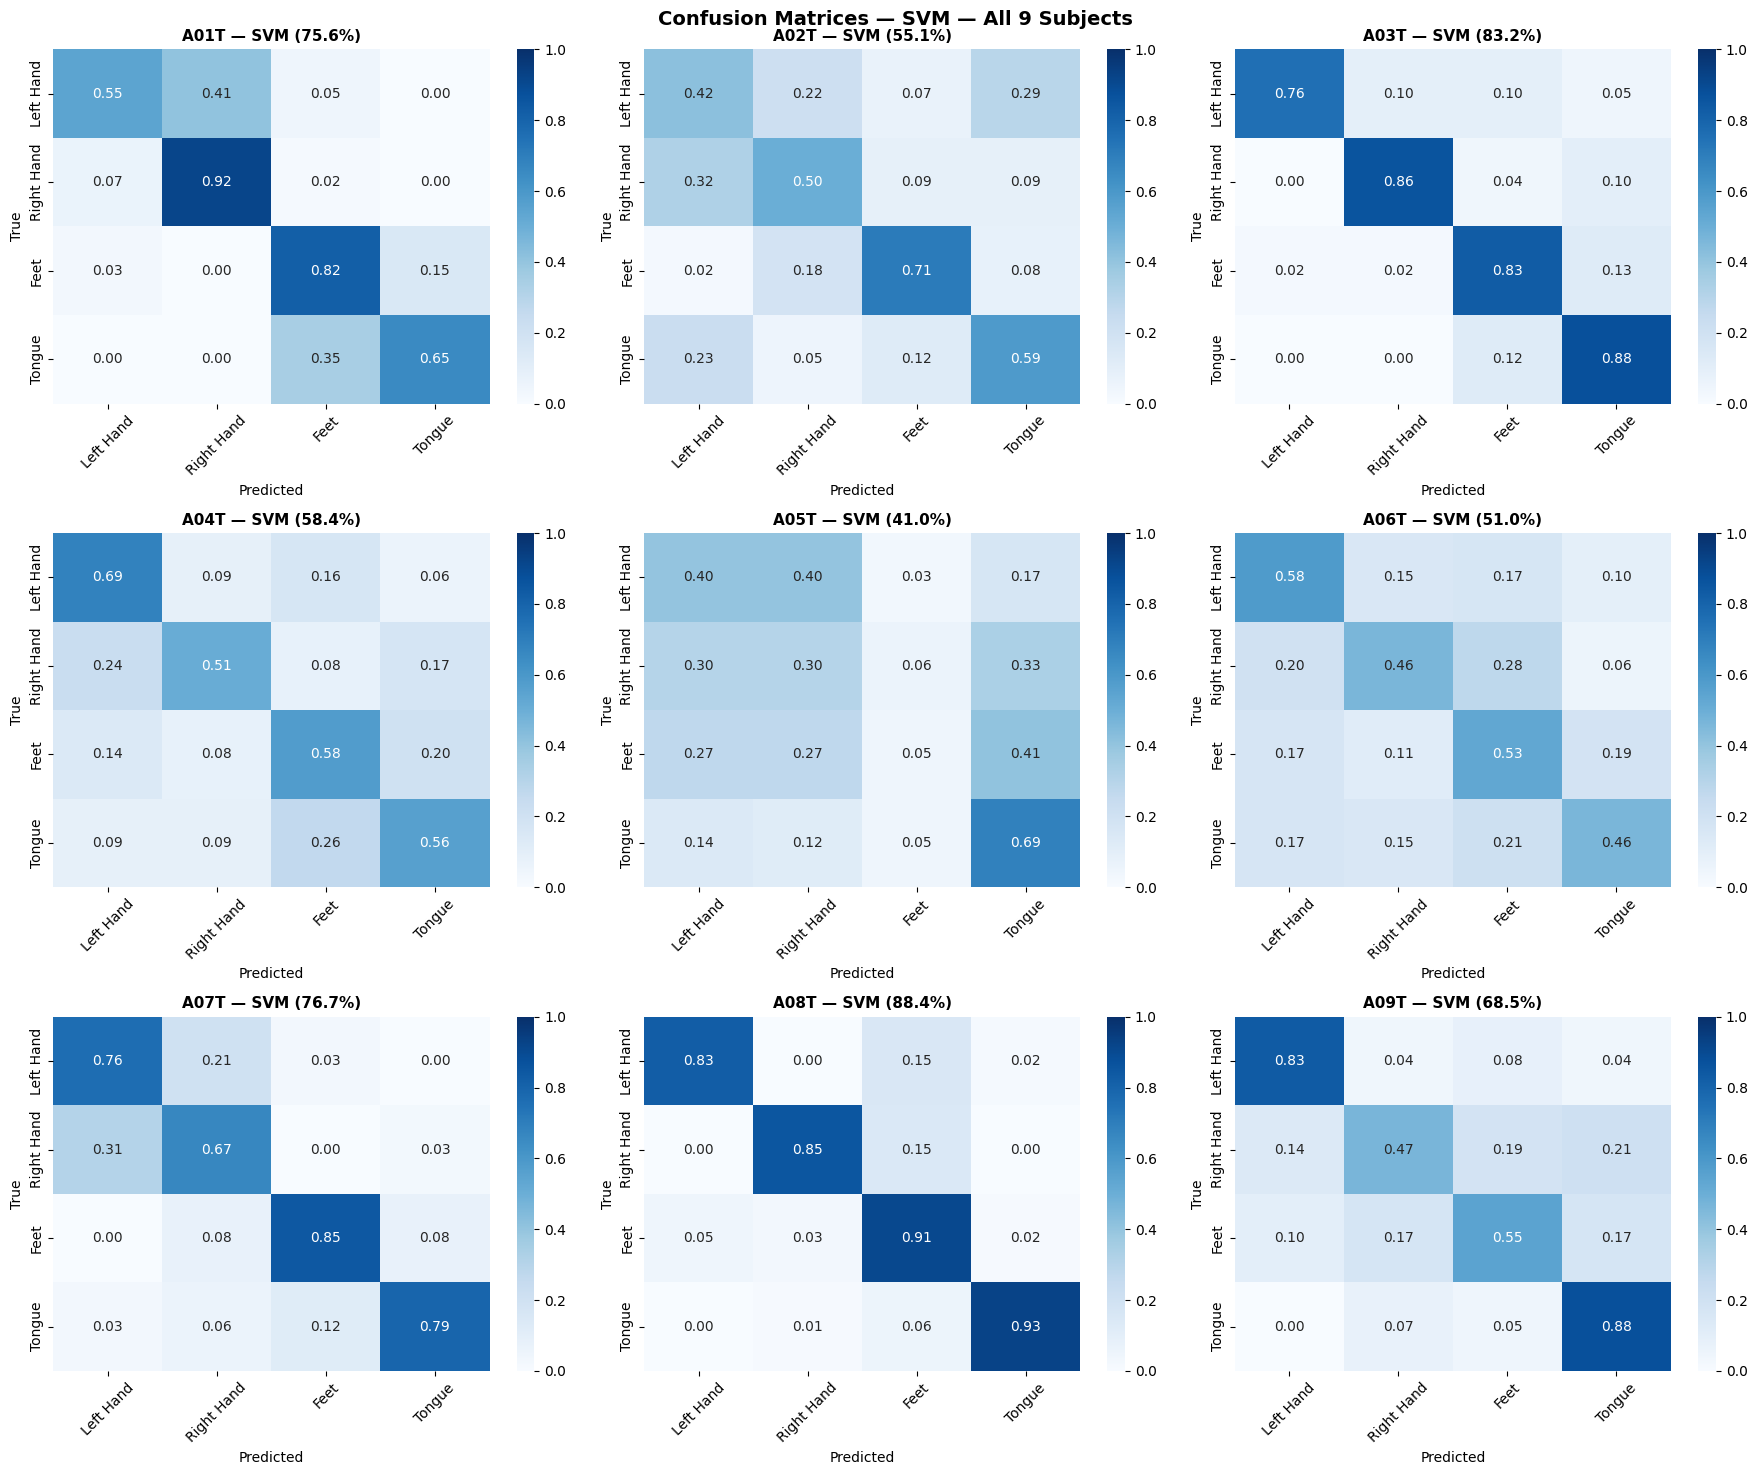

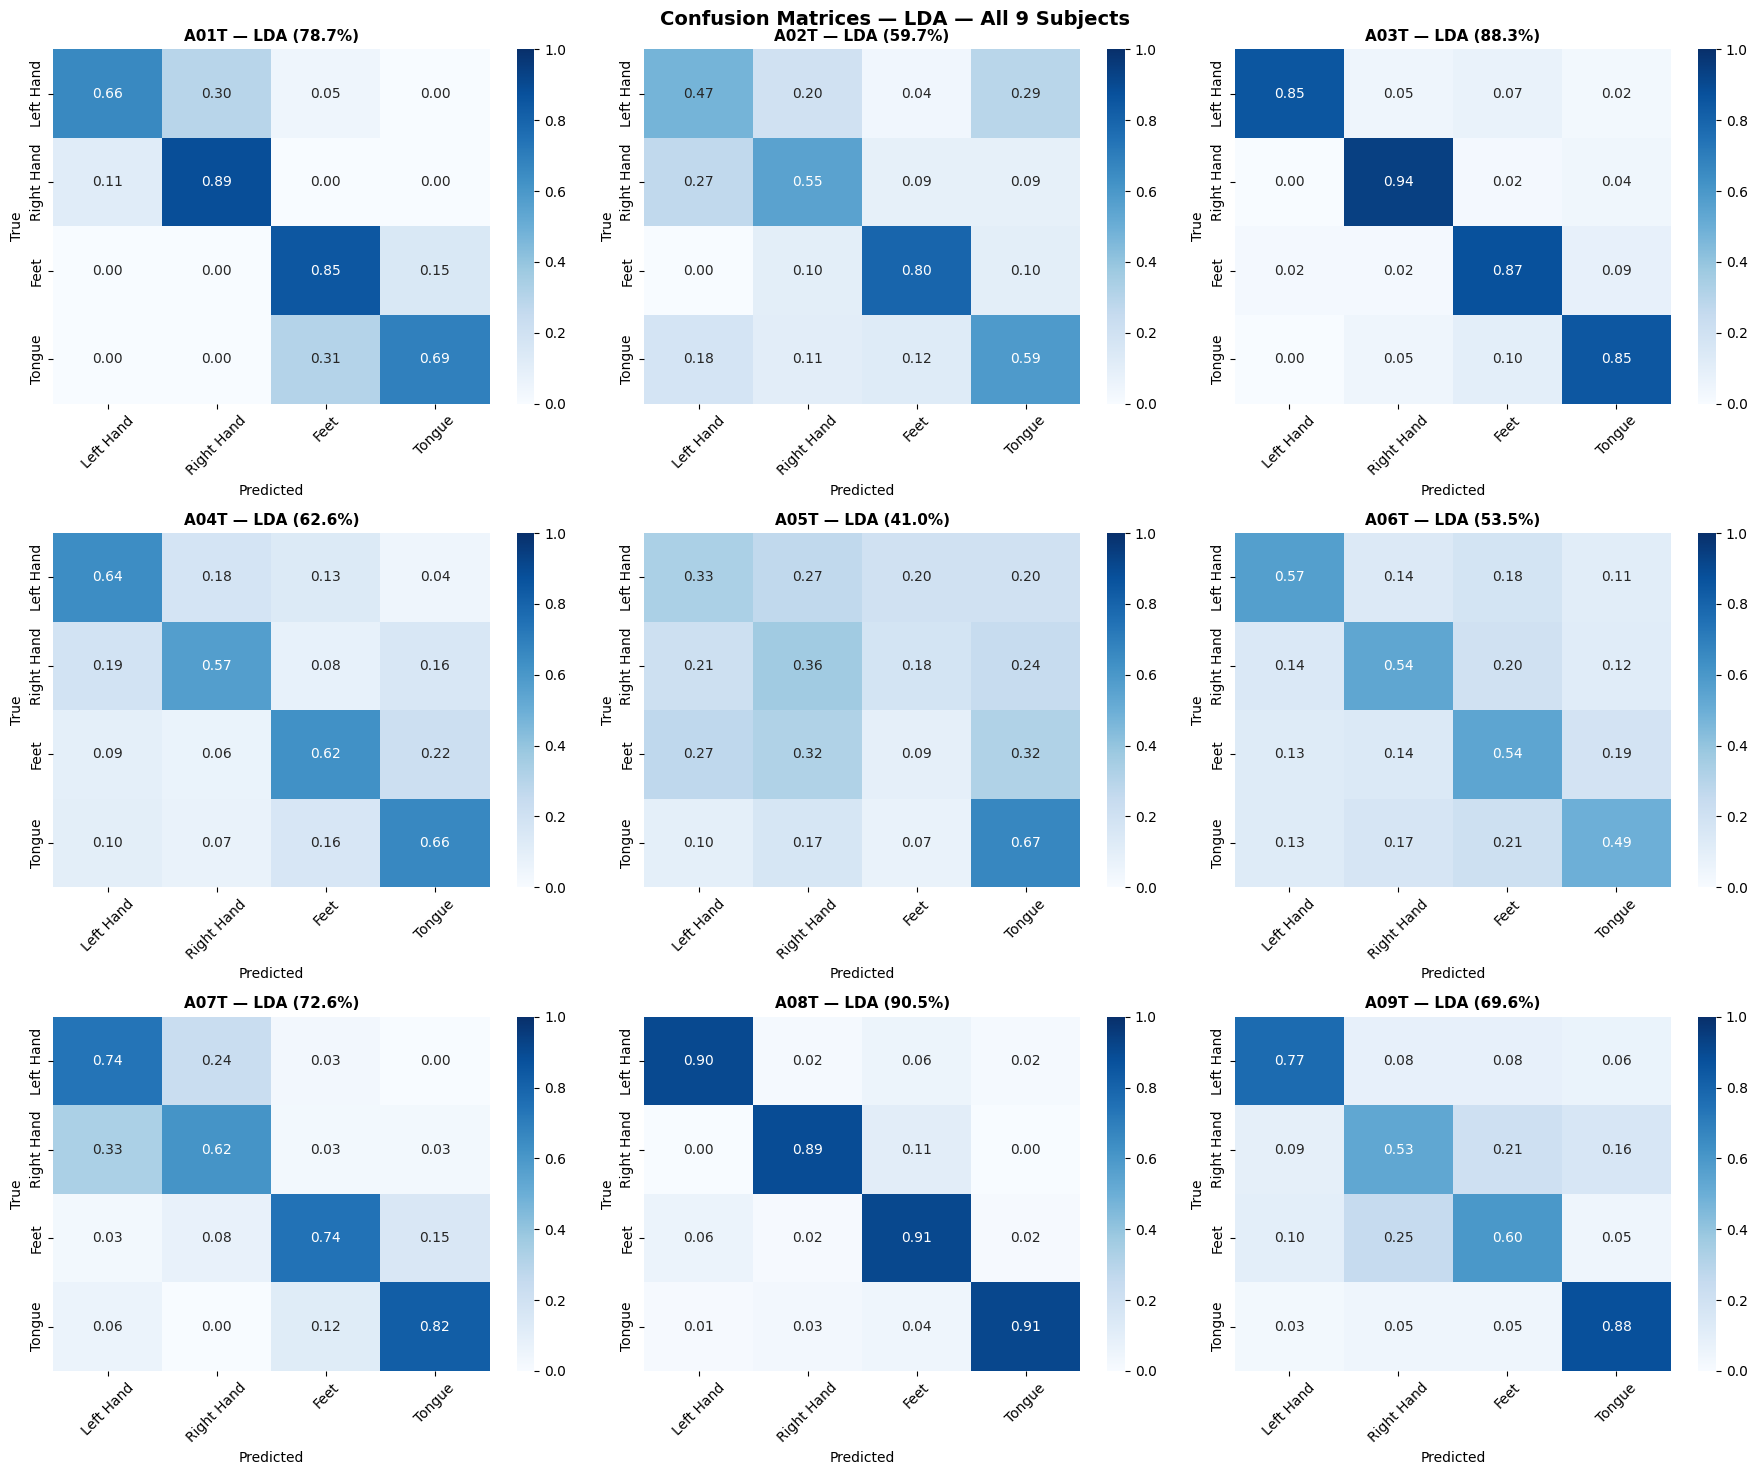

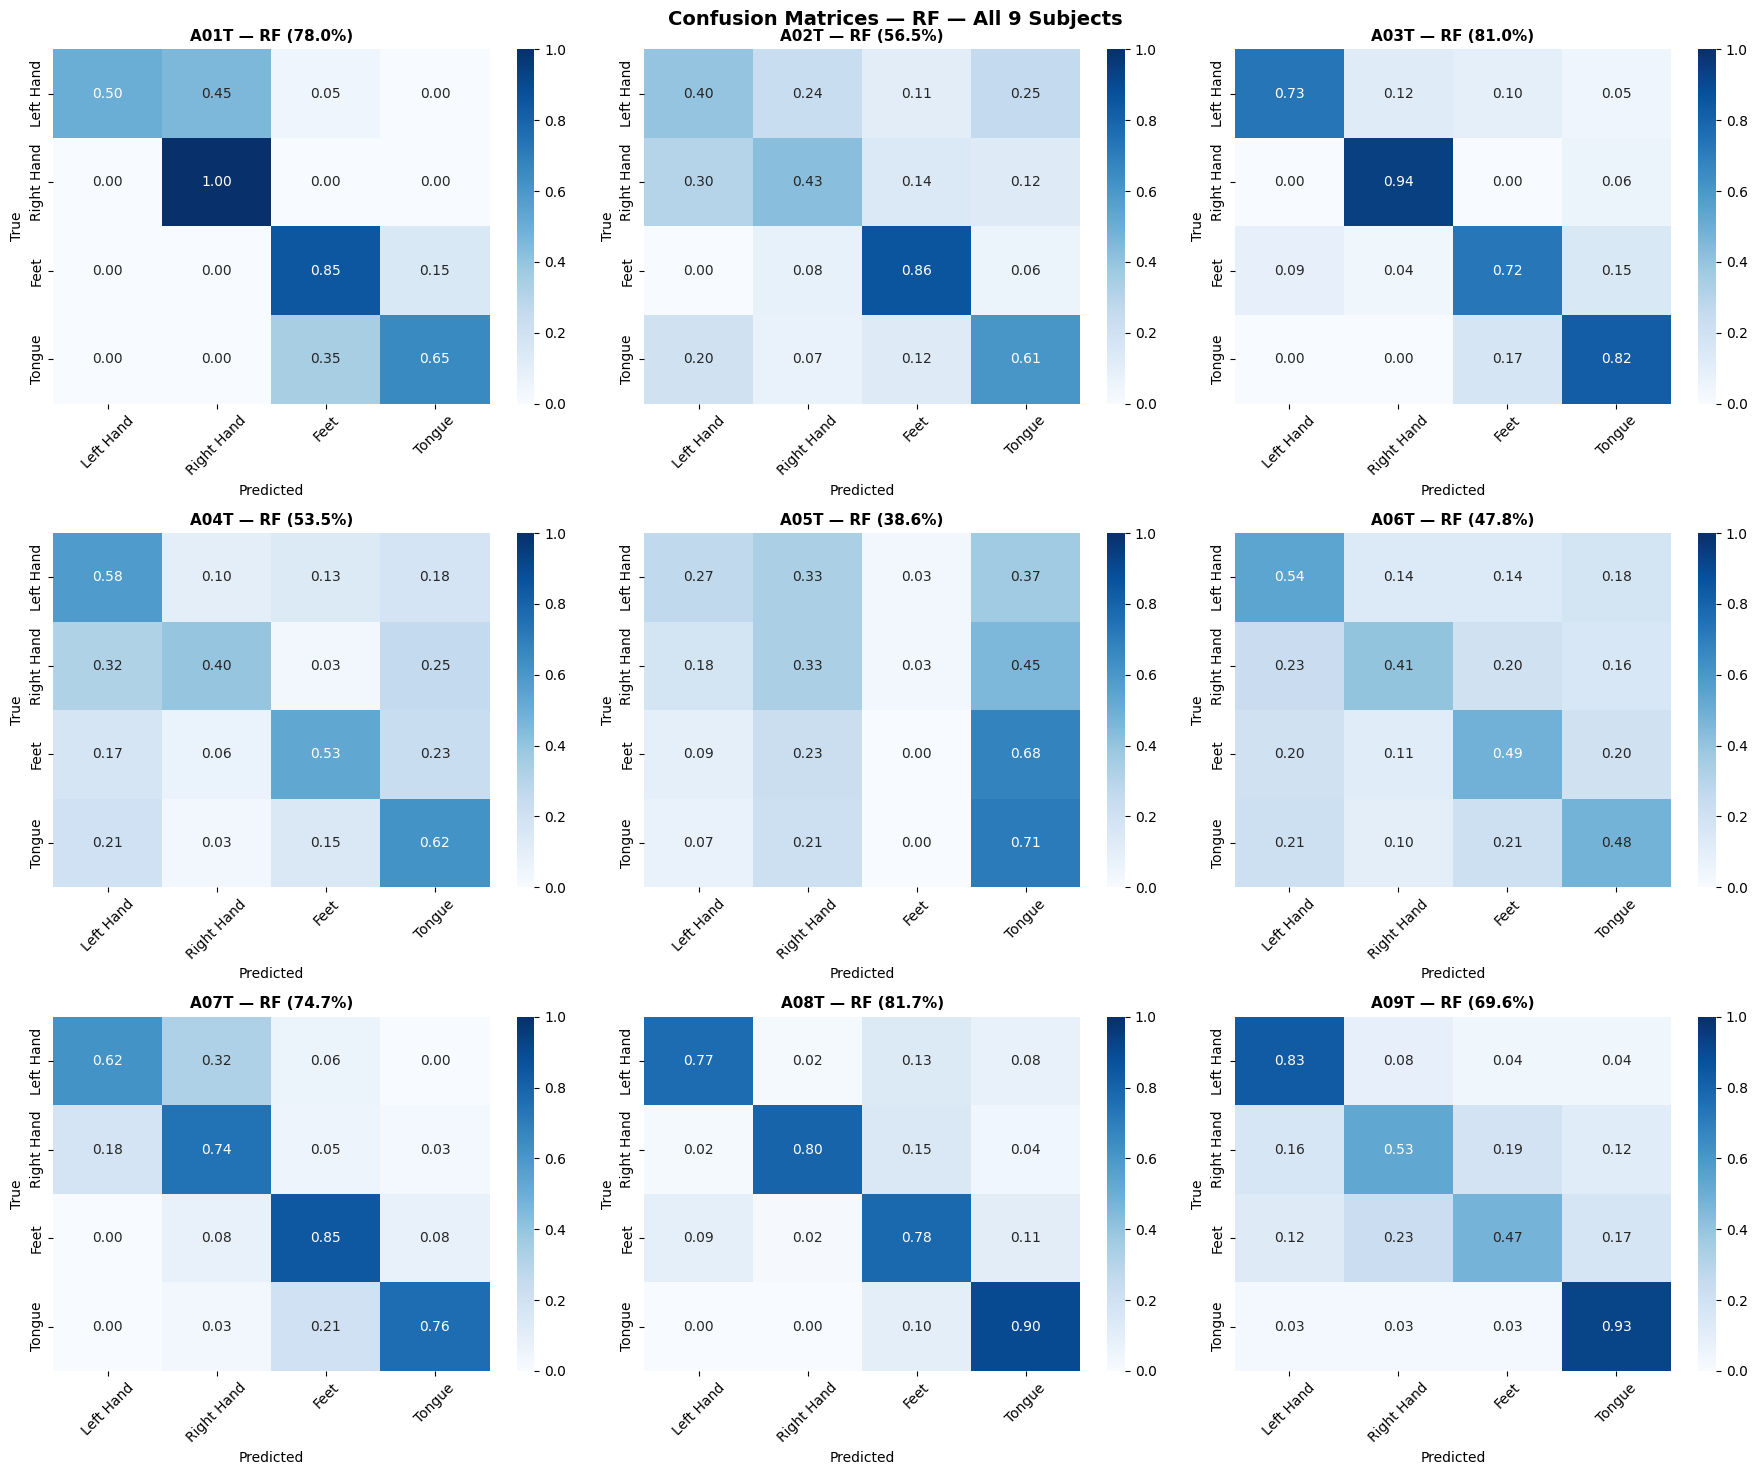

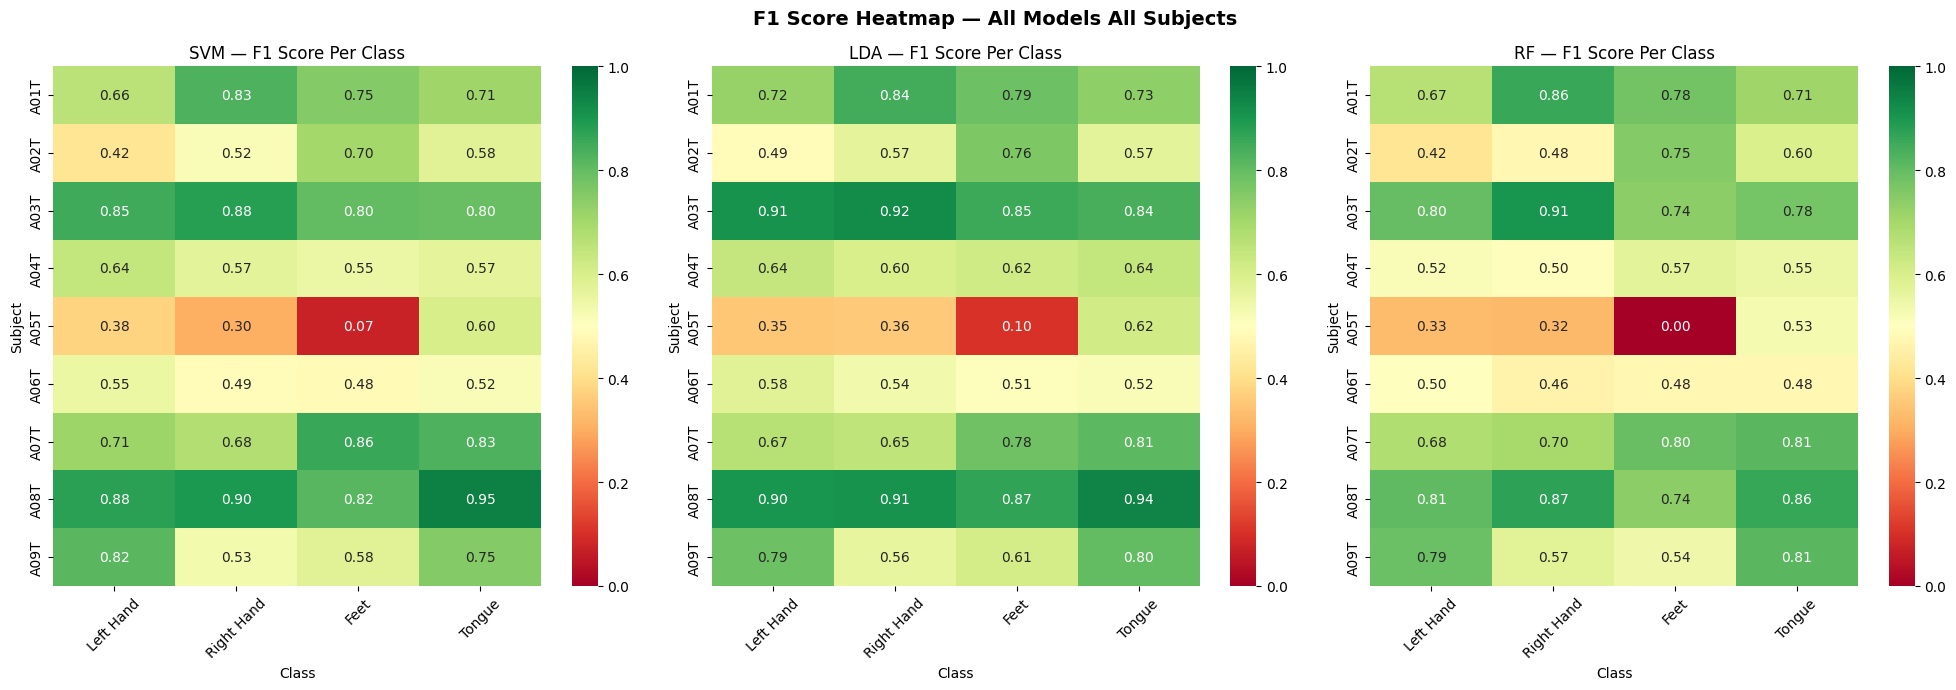

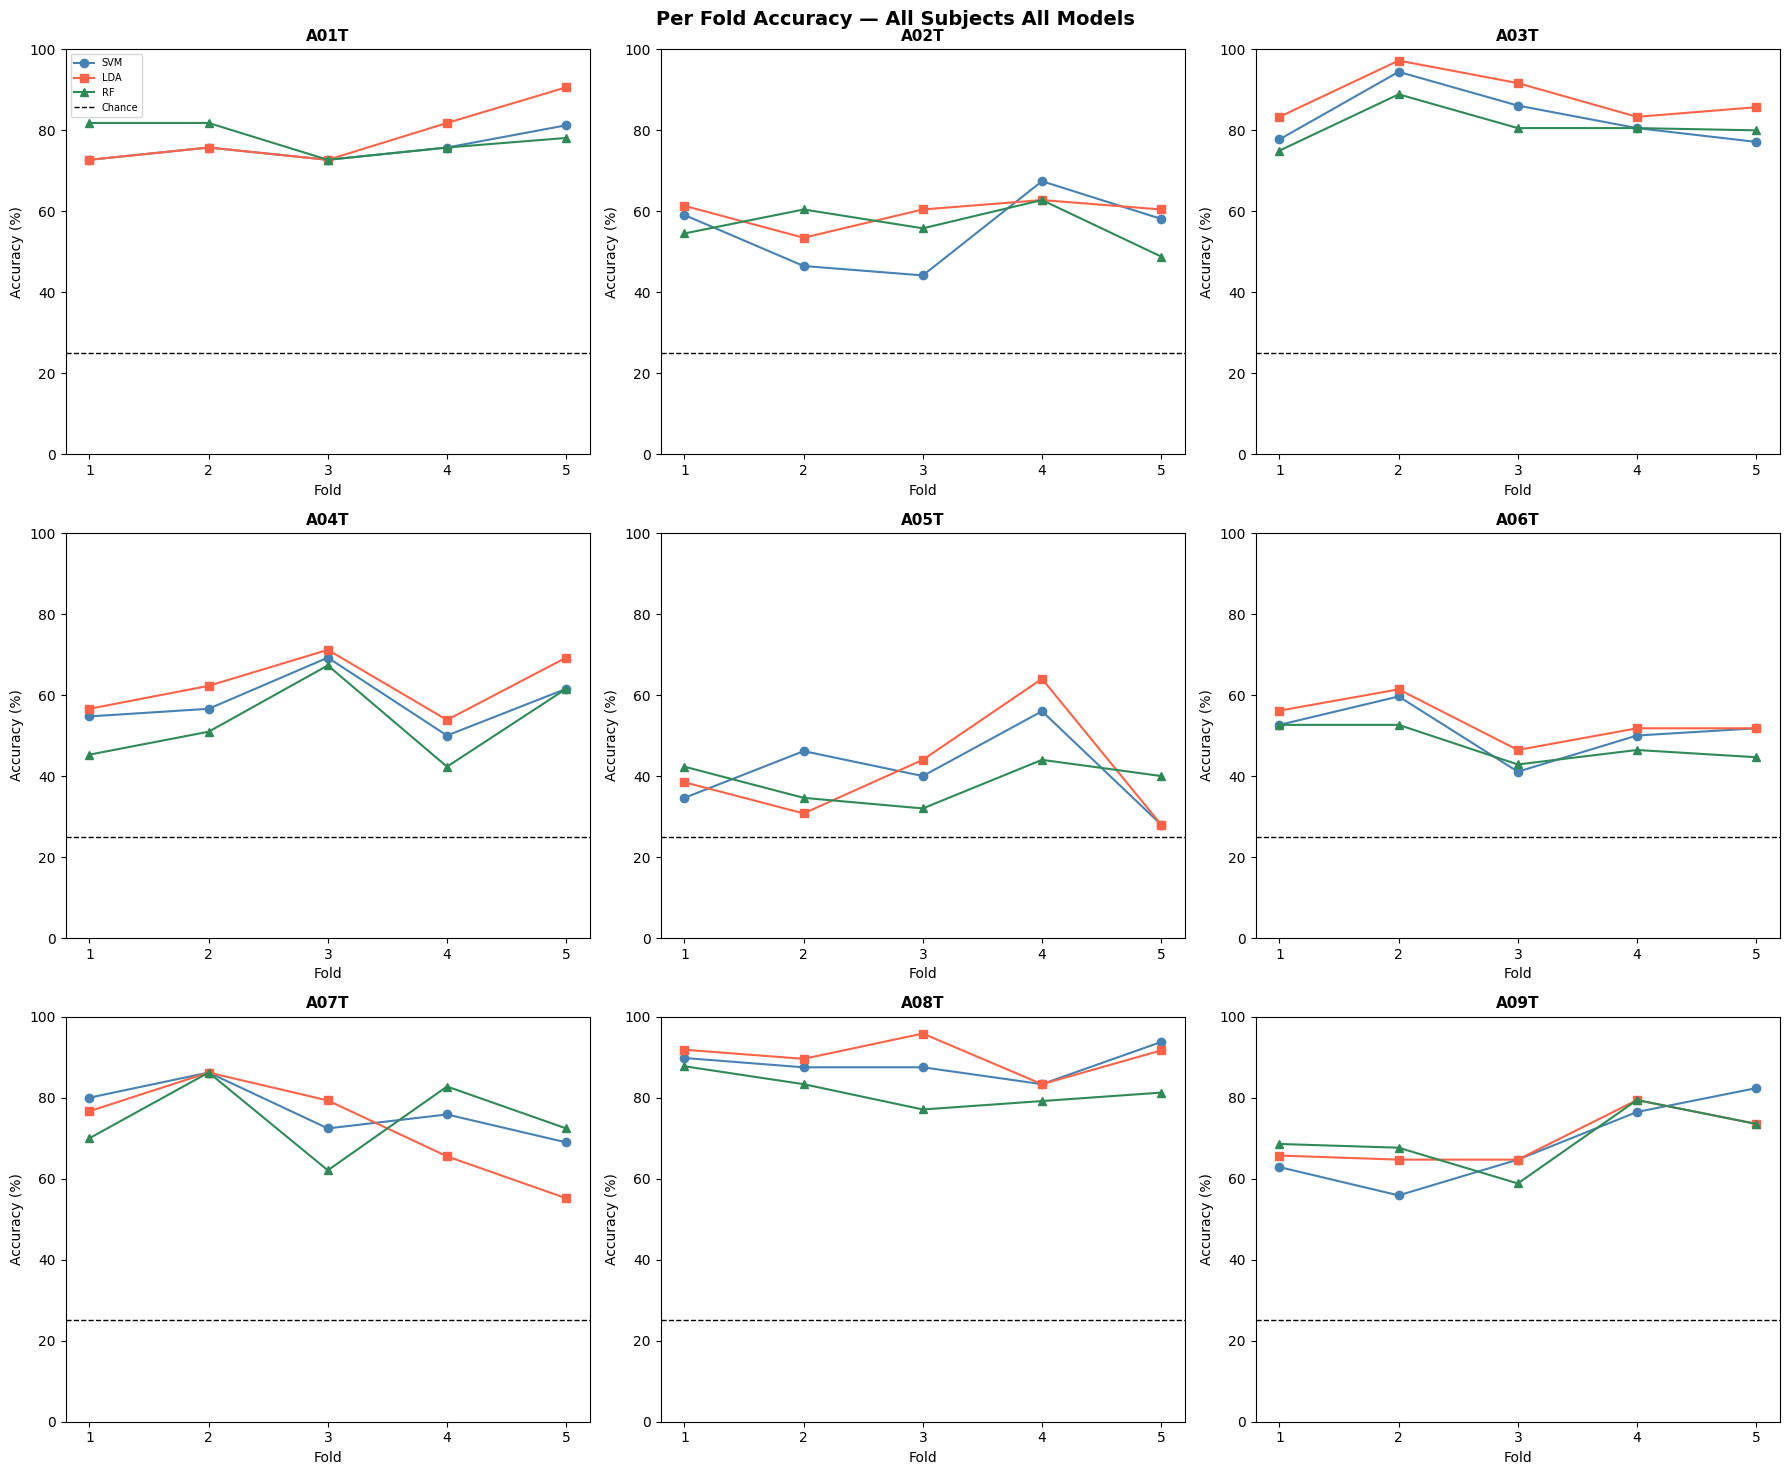

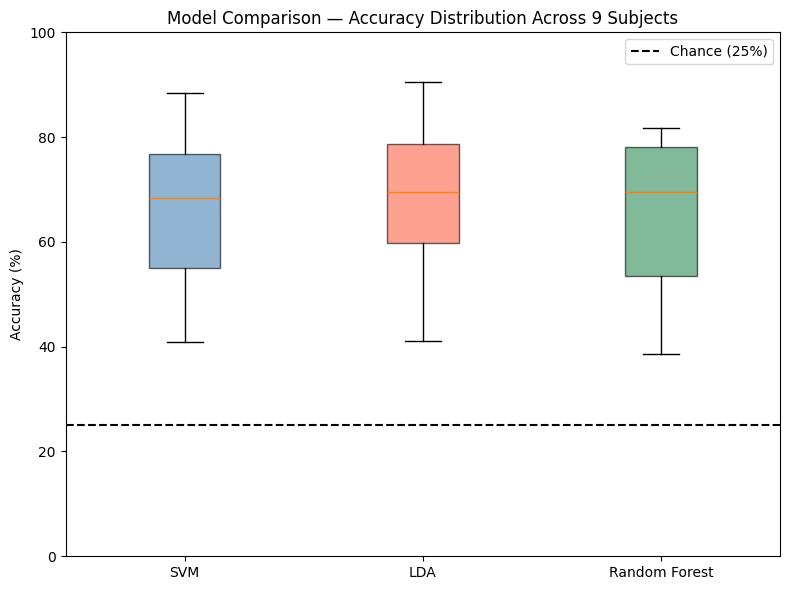

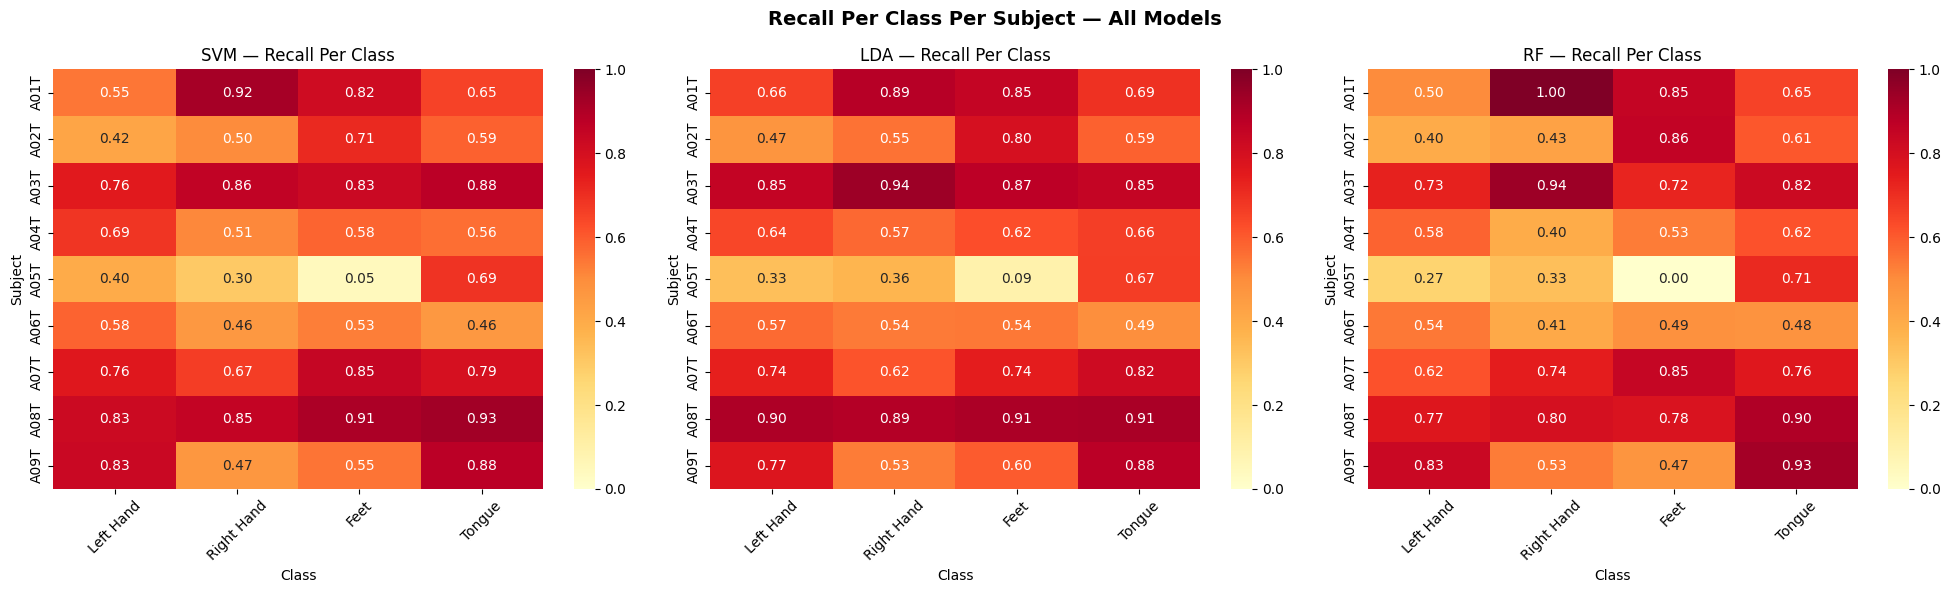

Best subject: A08T — 88.4%


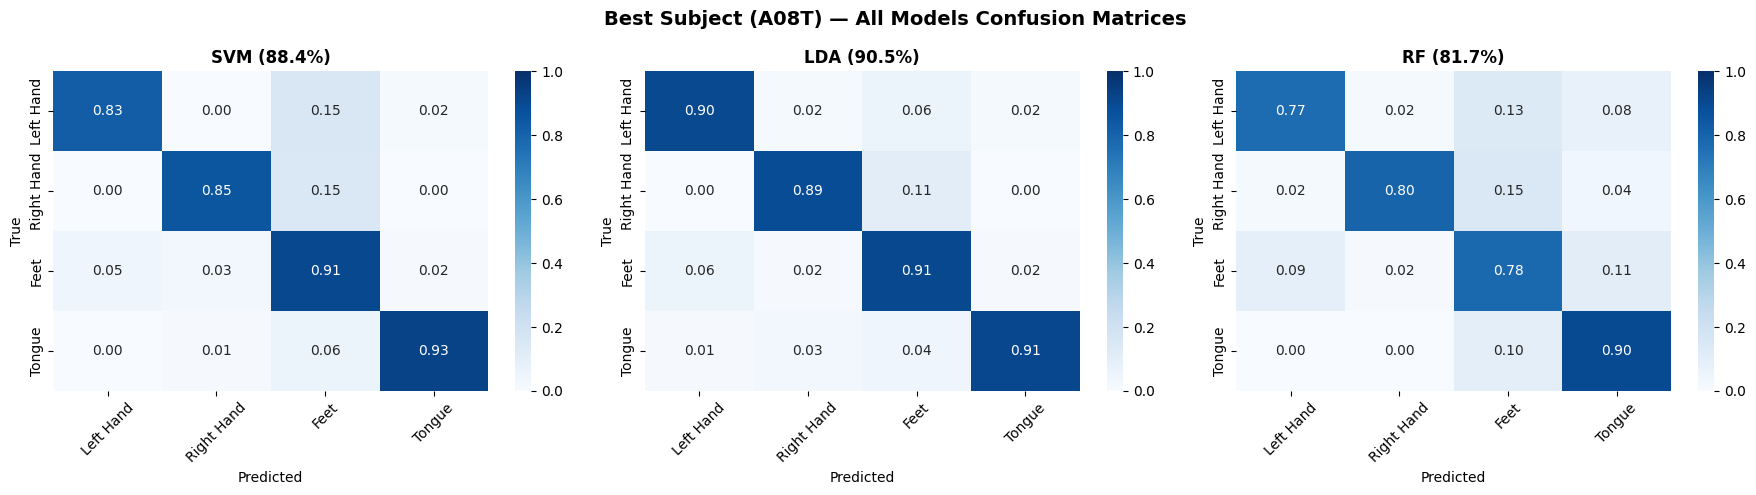

All training visualizations saved.


In [11]:
# Save metrics
save_metrics(all_results, subjects, save_path=METRICS_PATH)
run_all_visualizations(all_results, subjects, figures_path=FIGURES_PATH)